In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [57]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'], inplace= True)

    return df

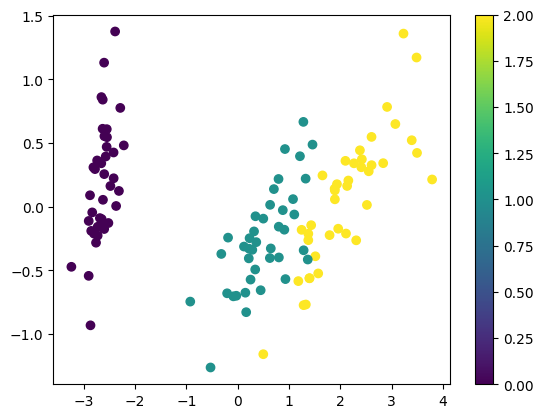

In [58]:
from sklearn.decomposition import PCA

pca= PCA(n_components=2, random_state= seed)

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= preprocess_data(train_df.drop(columns=['target']))
y_train= train_df['target']

X_test= preprocess_data(test_df)

plotter= pca.fit_transform(X_train)

plt.scatter(plotter[:, 0], plotter[:, 1], c= y_train)
plt.colorbar()
plt.show()

In [59]:
from sklearn.mixture import GaussianMixture

model= GaussianMixture(
    n_components= len(np.unique(y_train)),
    random_state= seed
)

model.fit(X_train, y_train)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [60]:
predictions= model.predict(X_test)

answer= pd.DataFrame({
    'SampleID': test_df['SampleID'],
    'label': predictions
})

answer.head()

,SampleID,label
0,39,0
1,128,2
2,58,1
3,94,1
4,43,0


In [61]:
answer.to_csv("submission.csv", index= False)